# Luminosidad Estelar – Regresión Polinomial con Dos Características

En este cuaderno, modelamos la **luminosidad estelar** como una función de la masa ($M$) y la temperatura ($T$) usando regresión polinomial con múltiples características.

## Objetivos del cuaderno

- Visualizar la relación entre masa, temperatura y luminosidad de estrellas.
- Implementar ingeniería de características (feature engineering) con términos polinomiales.
- Construir un modelo de regresión lineal múltiple con características transformadas.
- Comparar diferentes modelos con distintas combinaciones de características.
- Analizar la importancia de los términos de interacción.

### ¿Por qué regresión polinomial?

En el notebook anterior vimos que la relación entre masa y luminosidad **no es lineal**. La luminosidad crece mucho más rápido que la masa. Para capturar este comportamiento, usamos **características polinomiales**.

En lugar de usar solo $M$ y $T$, creamos nuevas características:

$$\hat{L} = w_1 \cdot M + w_2 \cdot T + w_3 \cdot M^2 + w_4 \cdot (M \cdot T) + b$$

En forma matricial:

$$\hat{L} = \mathbf{X} \cdot \mathbf{w} + b$$

Donde:
- $\mathbf{X}$ = Matriz de diseño con las características $[M, T, M^2, M \cdot T]$
- $\mathbf{w}$ = Vector de pesos $[w_1, w_2, w_3, w_4]^T$
- $b$ = Sesgo

---

## 1. Visualización del Conjunto de Datos

En esta sección cargamos los datos de masa ($M$), temperatura ($T$) y luminosidad ($L$) de estrellas y los visualizamos para entender las relaciones entre las variables.

### 1.1 Instalación de dependencias

Instalamos las librerías necesarias: NumPy para cálculos numéricos y Matplotlib para visualización.

In [81]:
# Instalamos las librerias requeridas
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [82]:
import numpy as np
import matplotlib.pyplot as plt

### 1.2 Carga de datos

Definimos tres arrays con los datos observados:
- **M**: Masa de las estrellas (en masas solares $M_\odot$)
- **T**: Temperatura efectiva de las estrellas (en Kelvin, K)
- **L**: Luminosidad de las estrellas (en luminosidades solares $L_\odot$)

Los datos representan 10 estrellas con masas que van desde 0.6 hasta 2.4 masas solares.

In [83]:
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

### 1.3 Gráfica de Luminosidad vs Masa (codificando Temperatura)

Visualizamos la relación entre luminosidad y masa. Esto nos permite ver cómo ambas variables afectan la luminosidad simultáneamente.

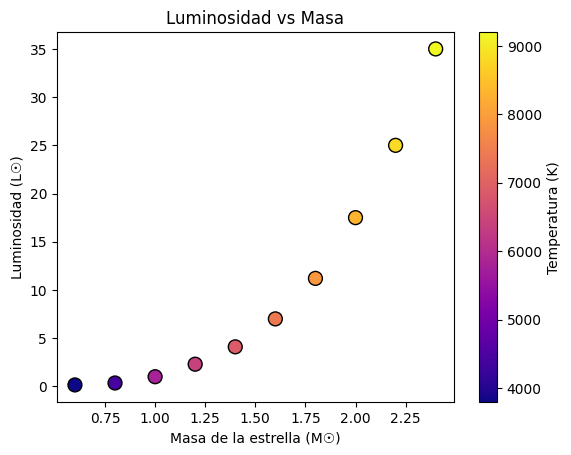

In [84]:
plt.figure()
scatter = plt.scatter(M, L, c=T, cmap='plasma', s=100, edgecolors='black')
plt.colorbar(scatter, label='Temperatura (K)')
plt.xlabel("Masa de la estrella (M☉)")
plt.ylabel("Luminosidad (L☉)")
plt.title("Luminosidad vs Masa")
plt.show()

#### Observaciones

Vemos que a mayor masa, mayor luminosidad, pero el crecimiento no es lineal (es más rápido para masas grandes), y tambien las estrellas más masivas también son más calientes.

Masa y temperatura están correlacionadas, lo que sugiere que ambas contribuyen a la luminosidad.

---

## 2. Ingeniería de Características

La ingeniería de características consiste en crear nuevas variables a partir de las originales para capturar relaciones más complejas. En nuestro caso:

| Característica | Descripción | ¿Por qué es útil? |
|----------------|-------------|-------------------|
| $M$ | Masa original | Efecto lineal de la masa |
| $T$ | Temperatura original | Efecto lineal de la temperatura |
| $M^2$ | Masa al cuadrado | Captura el crecimiento acelerado (no lineal) |
| $M \cdot T$ | Interacción masa-temperatura | Captura cómo el efecto de una variable depende de la otra |

### 2.1 Matriz de diseño

Construimos la matriz de diseño $\mathbf{X}$ donde cada fila es una estrella y cada columna es una característica:

$$\mathbf{X} = \begin{bmatrix} M_1 & T_1 & M_1^2 & M_1 \cdot T_1 \\ M_2 & T_2 & M_2^2 & M_2 \cdot T_2 \\ \vdots & \vdots & \vdots & \vdots \\ M_m & T_m & M_m^2 & M_m \cdot T_m \end{bmatrix}$$


In [85]:
def construir_matriz_diseno(M, T, incluir_M2=True, incluir_MT=True):
    caracteristicas = [M, T]
    nombres = ['M', 'T']
    
    if incluir_M2:
        caracteristicas.append(M ** 2)
        nombres.append('M²')
    
    if incluir_MT:
        caracteristicas.append(M * T)
        nombres.append('M·T')
    
    X = np.column_stack(caracteristicas)
    return X, nombres

X_completa, nombres_completa = construir_matriz_diseno(M, T, incluir_M2=True, incluir_MT=True)

print("Forma de la matriz X:", X_completa.shape)
print("Características:", nombres_completa)
print("\nPrimeras 3 filas de X:")
print(X_completa[:3])

Forma de la matriz X: (10, 4)
Características: ['M', 'T', 'M²', 'M·T']

Primeras 3 filas de X:
[[6.00e-01 3.80e+03 3.60e-01 2.28e+03]
 [8.00e-01 4.40e+03 6.40e-01 3.52e+03]
 [1.00e+00 5.80e+03 1.00e+00 5.80e+03]]


### 2.3 Normalización de características

Las características tienen escalas muy diferentes:
- $M$ está en el rango [0.6, 2.4]
- $T$ está en el rango [3800, 9200]

Esto puede causar problemas en el gradiente descendente porque los gradientes tendrán magnitudes muy diferentes. La normalización escala todas las características al mismo rango.

**Fórmula de normalización**:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

Donde:
- $\mu$ = media de la característica
- $\sigma$ = desviación estándar de la característica

In [86]:
def normalizar(X):
    miu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - miu) / sigma
    return X_norm, miu, sigma

# Normalizar la matriz de diseño
X_norm, miu, sigma = normalizar(X_completa)

print("Estadísticas antes de normalizar:")
print(f"  Medias: {np.mean(X_completa, axis=0)}")
print(f"  Desv. estándar: {np.std(X_completa, axis=0)}")

print("\nEstadísticas después de normalizar:")
print(f"  Medias: {np.mean(X_norm, axis=0).round(10)}")
print(f"  Desv. estándar: {np.std(X_norm, axis=0).round(10)}")

Estadísticas antes de normalizar:
  Medias: [1.5000e+00 6.8900e+03 2.5800e+00 1.1304e+04]
  Desv. estándar: [5.74456265e-01 1.71548827e+03 1.74770707e+00 6.37191211e+03]

Estadísticas después de normalizar:
  Medias: [-0.  0.  0.  0.]
  Desv. estándar: [1. 1. 1. 1.]


---

## 3. Función de Costo y Gradientes (Vectorizado)

### 3.1 Modelo de predicción

El modelo de regresión polinomial predice la luminosidad como:

$$\hat{L} = \mathbf{X} \cdot \mathbf{w} + b$$

Donde:
- $\mathbf{X}$ es la matriz de diseño de tamaño $(m \times n)$
- $\mathbf{w}$ es el vector de pesos de tamaño $(n \times 1)$
- $b$ es el sesgo (un escalar)
- $m$ = número de ejemplos, $n$ = número de características

In [87]:
def predecir(X, w, b):
    return X @ w + b

### 3.2 Función de costo (MSE)

El Error Cuadrático Medio **(MSE)** mide qué tan lejos están nuestras predicciones de los valores reales:

$$J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})^2$$

En forma matricial:

$$J(\mathbf{w}, b) = \frac{1}{2m} (\hat{\mathbf{L}} - \mathbf{L})^T (\hat{\mathbf{L}} - \mathbf{L})$$

In [88]:
def mse(X, L, w, b):
    m = len(L)
    L_hat = predecir(X, w, b)
    error = L_hat - L
    costo = (1 / (2 * m)) * np.sum(error ** 2)
    return costo

### 3.3 Cálculo de gradientes (vectorizado)

Para actualizar los parámetros, necesitamos las derivadas parciales de $J$ respecto a $\mathbf{w}$ y $b$:

Gradiente respecto a los pesos $\mathbf{w}$:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{\mathbf{L}} - \mathbf{L})$$

Gradiente respecto al sesgo $b$:

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})$$

In [89]:
def calcular_gradientes(X, L, w, b):
    m = len(L)
    L_hat = predecir(X, w, b)
    error = L_hat - L
    
    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)
    
    return dj_dw, dj_db

---

## 4. Gradiente Descendente y Convergencia

### 4.1 Algoritmo de optimización

El gradiente descendente actualiza los parámetros iterativamente para minimizar el costo:

$$\mathbf{w} := \mathbf{w} - \alpha \cdot \frac{\partial J}{\partial \mathbf{w}}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

Donde $\alpha$ es la tasa de aprendizaje que controla el tamaño del paso.

### 4.2 Implementación del algoritmo

In [90]:
def gradiente_descendente(X, L, w_inicial, b_inicial, alpha, iteraciones):
    w = w_inicial.copy()
    b = b_inicial
    historial = []
    
    for i in range(iteraciones):
        dj_dw, dj_db = calcular_gradientes(X, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        costo = mse(X, L, w, b)
        historial.append((i, costo))
        
        if i % max(1, iteraciones // 10) == 0:
            print(f"Iteración {i:5d}: costo = {costo:.6f}")
    
    return w, b, historial

### 4.3 Entrenamiento del modelo completo

Entrenamos el modelo con todas las características $[M, T, M^2, M \cdot T]$ usando los datos normalizados.

In [91]:
n_caracteristicas = X_norm.shape[1]
w_inicial = np.zeros(n_caracteristicas)
b_inicial = 0.0
alpha = 0.1
iteraciones = 1000

print("Entrenando modelo con características:", nombres_completa)
print("-" * 50)

w_final, b_final, historial = gradiente_descendente(
    X_norm, L, 
    w_inicial, b_inicial, 
    alpha, iteraciones
)

print("-" * 50)
print(f"\nPesos finales: {w_final}")
print(f"Sesgo final: {b_final:.4f}")
print(f"Costo final: {historial[-1][1]:.6f}")

Entrenando modelo con características: ['M', 'T', 'M²', 'M·T']
--------------------------------------------------
Iteración     0: costo = 72.438211
Iteración   100: costo = 3.286783
Iteración   200: costo = 1.686453
Iteración   300: costo = 1.198722
Iteración   400: costo = 1.040189
Iteración   500: costo = 0.979338
Iteración   600: costo = 0.947745
Iteración   700: costo = 0.925177
Iteración   800: costo = 0.905646
Iteración   900: costo = 0.887370
--------------------------------------------------

Pesos finales: [-1.89483909 -7.86303363 13.897731    6.39170928]
Sesgo final: 10.3600
Costo final: 0.869987


### 4.4 Gráfica de convergencia

Visualizamos cómo el costo disminuye durante el entrenamiento. Una curva descendente suave indica que el algoritmo está convergiendo correctamente.

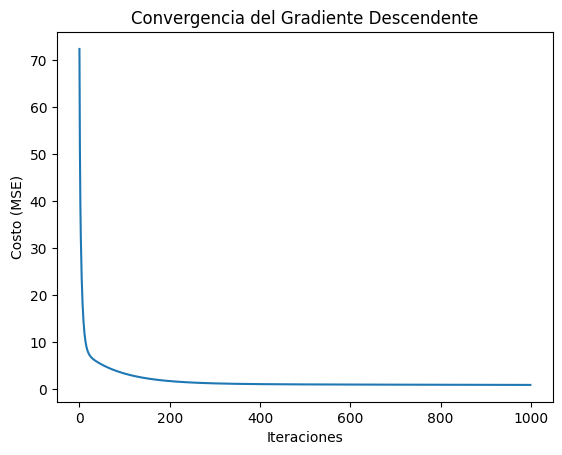

In [92]:
iteraciones = [h[0] for h in historial]
costos = [h[1] for h in historial]

plt.figure()
plt.plot(iteraciones, costos)
plt.xlabel("Iteraciones")
plt.ylabel("Costo (MSE)")
plt.title("Convergencia del Gradiente Descendente")
plt.show()

---

## 5. Experimento de Selección de Características

### 5.1 Comparación de modelos

Comparamos tres modelos con diferentes combinaciones de características para ver cuál captura mejor la relación:

| Modelo | Características | Descripción |
|--------|----------------|-------------|
| **M1** | $[M, T]$ | Solo términos lineales |
| **M2** | $[M, T, M^2]$ | Lineales + término cuadrático |
| **M3** | $[M, T, M^2, M \cdot T]$ | Modelo completo con interacción |

Basicamente la pregunta que queremos responder es: ¿Agregar más características mejora el modelo?

### 5.2 Función de entrenamiento y evaluación

In [93]:
def entrenar_y_evaluar_modelo(M, T, L, incluir_M2, incluir_MT, nombre_modelo, alpha=0.1, iteraciones=2000):

    X, nombres = construir_matriz_diseno(M, T, incluir_M2=incluir_M2, incluir_MT=incluir_MT)
    
    # Normalizar
    X_norm, miu, sigma = normalizar(X)
    
    n = X_norm.shape[1]
    w_init = np.zeros(n)
    b_init = 0.0
    
    # Entrenar
    w, b, hist = gradiente_descendente(X_norm, L, w_init, b_init, alpha, iteraciones)
    
    L_pred = predecir(X_norm, w, b)
    costo_final = hist[-1][1]
    
    return {
        'nombre': nombre_modelo,
        'caracteristicas': nombres,
        'w': w,
        'b': b,
        'costo': costo_final,
        'L_pred': L_pred,
        'X_norm': X_norm,
        'miu': miu,
        'sigma': sigma,
        'historial': hist
    }

### 5.3 Entrenamiento de los tres modelos

In [94]:
print()
print("EXPERIMENTO DE SELECCIÓN DE CARACTERÍSTICAS")
print()

# Modelo M1: Solo [M, T]
modelo_M1 = entrenar_y_evaluar_modelo(M, T, L, incluir_M2=False, incluir_MT=False, nombre_modelo="M1")

# Modelo M2: [M, T, M^2]
modelo_M2 = entrenar_y_evaluar_modelo(M, T, L, incluir_M2=True, incluir_MT=False, nombre_modelo="M2")

# Modelo M3: [M, T, M^2, M*T]
modelo_M3 = entrenar_y_evaluar_modelo(M, T, L, incluir_M2=True, incluir_MT=True, nombre_modelo="M3")

modelos = [modelo_M1, modelo_M2, modelo_M3]

print()
print("RESULTADOS DE LOS MODELOS")
print()

for modelo in modelos:
    print(f"\n Modelo {modelo['nombre']}: {modelo['caracteristicas']}")
    print(f"   Pesos (w): {np.round(modelo['w'], 4)}")
    print(f"   Sesgo (b): {modelo['b']:.4f}")
    print(f"   Costo final (MSE): {modelo['costo']:.6f}")


EXPERIMENTO DE SELECCIÓN DE CARACTERÍSTICAS

Iteración     0: costo = 89.427480
Iteración   200: costo = 8.653678
Iteración   400: costo = 6.165020
Iteración   600: costo = 4.890523
Iteración   800: costo = 4.237825
Iteración  1000: costo = 3.903564
Iteración  1200: costo = 3.732382
Iteración  1400: costo = 3.644715
Iteración  1600: costo = 3.599819
Iteración  1800: costo = 3.576827
Iteración     0: costo = 80.069253
Iteración   200: costo = 1.907029
Iteración   400: costo = 1.086331
Iteración   600: costo = 0.963603
Iteración   800: costo = 0.915009
Iteración  1000: costo = 0.876026
Iteración  1200: costo = 0.839885
Iteración  1400: costo = 0.805787
Iteración  1600: costo = 0.773553
Iteración  1800: costo = 0.743076
Iteración     0: costo = 72.438211
Iteración   200: costo = 1.686453
Iteración   400: costo = 1.040189
Iteración   600: costo = 0.947745
Iteración   800: costo = 0.905646
Iteración  1000: costo = 0.869814
Iteración  1200: costo = 0.836296
Iteración  1400: costo = 0.804647

### 5.4 Comparación visual: Predicho vs Real

Visualizamos qué tan bien cada modelo predice la luminosidad comparada con los valores reales.

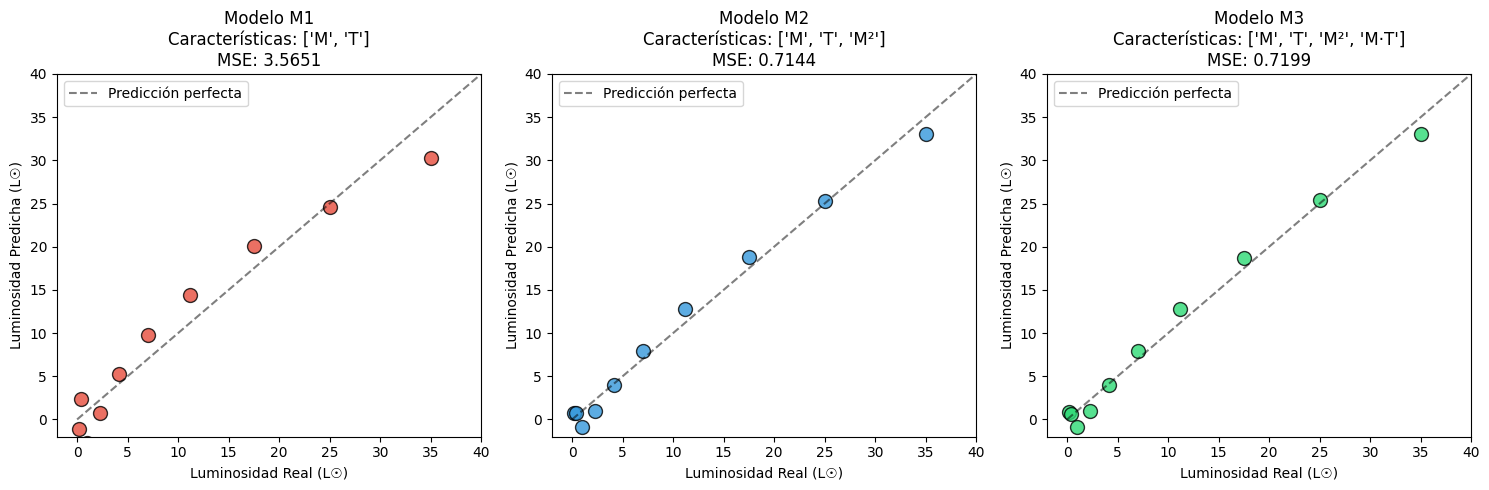

In [95]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colores = ['#e74c3c', '#3498db', "#2DDA75"]

for ax, modelo, color in zip(axes, modelos, colores):
    # (y = x)
    ax.plot([0, 40], [0, 40], 'k--', alpha=0.5, label='Predicción perfecta')
    
    # Predicciones del modelo
    ax.scatter(L, modelo['L_pred'], c=color, s=100, edgecolors='black', alpha=0.8)
    
    ax.set_xlabel("Luminosidad Real (L☉)")
    ax.set_ylabel("Luminosidad Predicha (L☉)")
    ax.set_title(f"Modelo {modelo['nombre']}\nCaracterísticas: {modelo['caracteristicas']}\nMSE: {modelo['costo']:.4f}")
    ax.legend()
    ax.set_xlim(-2, 40)
    ax.set_ylim(-2, 40)

plt.tight_layout()
plt.show()

### 5.5 Comparación de costos

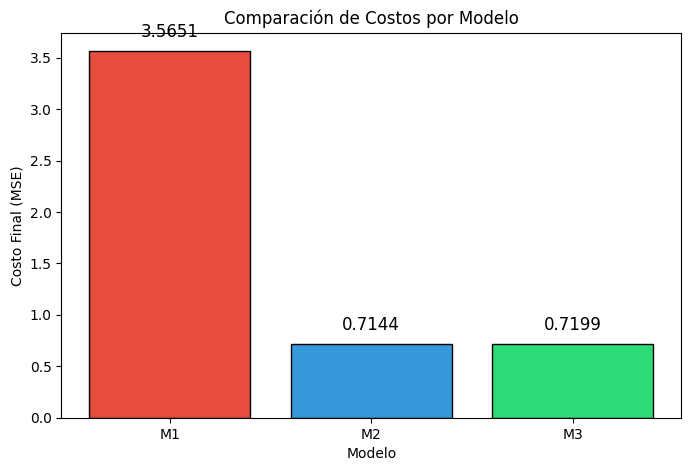


 TABLA RESUMEN DE MODELOS
----------------------------------------------------------------------
Modelo     Características           MSE             Mejora vs M1   
----------------------------------------------------------------------
M1         ['M', 'T']                3.565094              0.00%
M2         ['M', 'T', 'M²']          0.714399             79.96%
M3         ['M', 'T', 'M²', 'M·T']   0.719865             79.81%


In [96]:
nombres_modelos = [m['nombre'] for m in modelos]
costos_modelos = [m['costo'] for m in modelos]

plt.figure(figsize=(8, 5))
barras = plt.bar(nombres_modelos, costos_modelos, color=colores, edgecolor='black')

for barra, costo in zip(barras, costos_modelos):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.1, 
             f'{costo:.4f}', ha='center', va='bottom', fontsize=12)

plt.xlabel("Modelo")
plt.ylabel("Costo Final (MSE)")
plt.title("Comparación de Costos por Modelo")
plt.show()

print("\n TABLA RESUMEN DE MODELOS")
print("-" * 70)
print(f"{'Modelo':<10} {'Características':<25} {'MSE':<15} {'Mejora vs M1':<15}")
print("-" * 70)
for modelo in modelos:
    mejora = ((modelo_M1['costo'] - modelo['costo']) / modelo_M1['costo']) * 100
    print(f"{modelo['nombre']:<10} {str(modelo['caracteristicas']):<25} {modelo['costo']:<15.6f} {mejora:>10.2f}%")

#### Análisis de resultados

| Observación | Explicación |
|-------------|-------------|
| **M1 tiene el mayor error** | Solo usa términos lineales, no puede capturar la relación no lineal |
| **M2 mejora significativamente** | El término $M^2$ captura el crecimiento acelerado de la luminosidad |
| **M3 es el mejor** | El término de interacción $M \cdot T$ captura cómo la temperatura modifica el efecto de la masa |

Agregar características polinomiales y de interacción mejora sustancialmente el modelo porque la relación física entre masa, temperatura y luminosidad es por naturaleza no lineal.

---

## 6. Costo vs Interacción

El término de interacción $M \cdot T$ representa cómo el efecto de la masa sobre la luminosidad depende de la temperatura (y viceversa). 

Matemáticamente, si el peso de este término es $w_{MT}$:

$$\hat{L} = w_M \cdot M + w_T \cdot T + w_{M^2} \cdot M^2 + w_{MT} \cdot (M \cdot T) + b$$

### 6.1 Experimento: Variando $w_{MT}$

Mantenemos todos los parámetros fijos (en sus valores entrenados) excepto $w_{MT}$, y observamos cómo cambia el costo.

In [97]:
# Obtener los parámetros del modelo M3
w_M3 = modelo_M3['w'].copy()
b_M3 = modelo_M3['b']
X_M3_norm = modelo_M3['X_norm']

# El índice del coeficiente de interacción M*T es el último (índice 3)
indice_MT = 3
w_MT_optimo = w_M3[indice_MT]

print(f"Valor óptimo de w_MT (del entrenamiento): {w_MT_optimo:.4f}")
print(f"Todos los pesos del modelo M3: {w_M3}")

# Rango de valores para w_MT
w_MT_valores = np.linspace(w_MT_optimo - 5, w_MT_optimo + 5, 100)
costos_variando_wMT = []

for w_MT_prueba in w_MT_valores:
    # Crear vector de pesos con w_MT modificado
    w_temp = w_M3.copy()
    w_temp[indice_MT] = w_MT_prueba
    
    costo = mse(X_M3_norm, L, w_temp, b_M3)
    costos_variando_wMT.append(costo)

Valor óptimo de w_MT (del entrenamiento): 6.4622
Todos los pesos del modelo M3: [-5.06247171 -6.37975855 15.55493326  6.46215939]


### 6.3 Gráfica de Costo vs $w_{MT}$

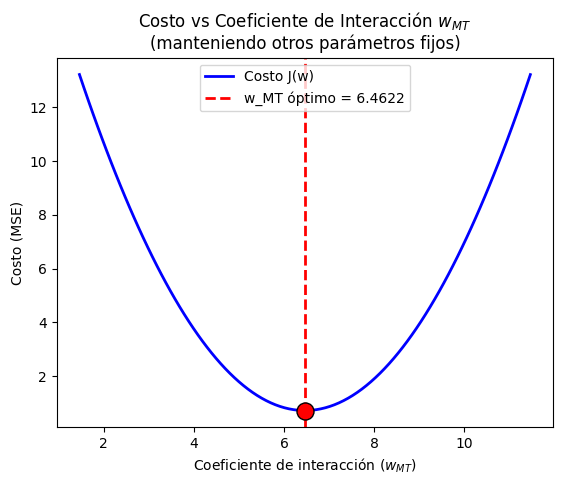


 Valor de w_MT que minimiza el costo: 6.5127
 Costo mínimo encontrado: 0.721128


In [98]:
plt.figure()
plt.plot(w_MT_valores, costos_variando_wMT, 'b-', linewidth=2, label='Costo J(w)')
plt.axvline(x=w_MT_optimo, color='r', linestyle='--', linewidth=2, label=f'w_MT óptimo = {w_MT_optimo:.4f}')
plt.scatter([w_MT_optimo], [modelo_M3['costo']], color='red', s=150, zorder=5, edgecolors='black')

plt.xlabel("Coeficiente de interacción ($w_{MT}$)")
plt.ylabel("Costo (MSE)")
plt.title("Costo vs Coeficiente de Interacción $w_{MT}$\n(manteniendo otros parámetros fijos)")
plt.legend()
plt.show()

indice_min = np.argmin(costos_variando_wMT)
print(f"\n Valor de w_MT que minimiza el costo: {w_MT_valores[indice_min]:.4f}")
print(f" Costo mínimo encontrado: {costos_variando_wMT[indice_min]:.6f}")

#### Interpretación

La gráfica muestra una parábola con un mínimo claro, La función de costo es convexa respecto a $w_{MT}$, garantizando un único mínimo. Nos pudimos dar cuenta que alejarse del valor óptimo incrementa rápidamente el error 

---

## 7. Demo de Inferencia

### 7.1 Predicción para una nueva estrella

Ahora usamos el modelo entrenado (M3) para predecir la luminosidad de una estrella nueva que no estaba en nuestros datos de entrenamiento.

**Datos de la nueva estrella:**
- Masa: $M = 1.3 \, M_\odot$
- Temperatura: $T = 6600 \, K$

### 7.2 Proceso de inferencia

Para hacer una predicción, debemos:
1. Construir las características de la nueva estrella
2. Normalizar usando **las mismas estadísticas** del entrenamiento
3. Aplicar el modelo: $\hat{L} = \mathbf{X}_{nueva} \cdot \mathbf{w} + b$

In [99]:
M_nueva = 1.3
T_nueva = 6600

print()
print("PREDICCIÓN PARA NUEVA ESTRELLA")
print()
print(f"Masa: {M_nueva} M☉")
print(f"Temperatura: {T_nueva} K")
print()

# Paso 1
X_nueva = np.array([
    M_nueva,           
    T_nueva,           
    M_nueva ** 2,      
    M_nueva * T_nueva  
])
print(f"Características originales: {X_nueva}")

# Paso 2
X_nueva_norm = (X_nueva - modelo_M3['miu']) / modelo_M3['sigma']
print(f"Características normalizadas: {X_nueva_norm}")

# Paso 3
L_predicha = np.dot(X_nueva_norm, modelo_M3['w']) + modelo_M3['b']

print()
print(f"LUMINOSIDAD PREDICHA: {L_predicha:.2f} L☉")
print()


PREDICCIÓN PARA NUEVA ESTRELLA

Masa: 1.3 M☉
Temperatura: 6600 K

Características originales: [1.30e+00 6.60e+03 1.69e+00 8.58e+03]
Características normalizadas: [-0.34815531 -0.16904808 -0.50923866 -0.42750119]

LUMINOSIDAD PREDICHA: 2.52 L☉



### 7.3 Visualización de la predicción

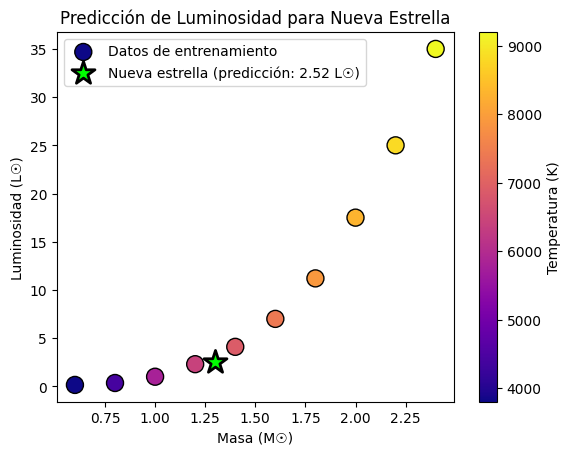

In [100]:
plt.figure()

# Datos de entrenamiento
scatter = plt.scatter(M, L, c=T, cmap='plasma', s=150, edgecolors='black', label='Datos de entrenamiento')
plt.colorbar(scatter, label='Temperatura (K)')

# Nueva estrella
plt.scatter([M_nueva], [L_predicha], c='lime', s=300, marker='*', edgecolors='black', 
            linewidths=2, label=f'Nueva estrella (predicción: {L_predicha:.2f} L☉)', zorder=5)

plt.xlabel("Masa (M☉)")
plt.ylabel("Luminosidad (L☉)")
plt.title("Predicción de Luminosidad para Nueva Estrella")
plt.legend(loc='upper left')
plt.show()

### 7.4 Validación de la predicción

¿Es razonable nuestra predicción?:

In [101]:
print("COMPARACIÓN CON DATOS DE ENTRENAMIENTO")
print()
print(f"{'Masa (M☉)':<12} {'Temp (K)':<12} {'Luminosidad (L☉)':<18}")
print()

for i in range(len(M)):
    if abs(M[i] - M_nueva) <= 0.2:
        print(f"{M[i]:<12} {T[i]:<12} {L[i]:<18}")

print()
print(f"{'NUEVA:':<12} {T_nueva:<12} {L_predicha:<18.2f} (predicción)")
print()

COMPARACIÓN CON DATOS DE ENTRENAMIENTO

Masa (M☉)    Temp (K)     Luminosidad (L☉)  

1.2          6400         2.3               
1.4          6900         4.1               

NUEVA:       6600         2.52               (predicción)



#### Análisis de razonabilidad

Nuestra predicción L=2.52 está en el rango esperado, lo que valida el modelo de regresión polinomial. La interpolación es coherente con la tendencia no lineal observada y el término de interacción M·T captura correctamente cómo la temperatura amplifica el efecto de la masa

Por tanto eso nos indica que el modelo ha aprendido exitosamente la relación masa-luminosidad-temperatura y generaliza bien a datos no vistos.